In [1]:
pip install pyampute

In [2]:
#read the file
#local system location: C:\Users\DELL\Downloads\archive.zip
import pandas as pd
import seaborn as sns
import pyampute
titanic_file=pd.read_csv('/content/train.csv')

kurt - skew>0 tail to the right skew <0 tail to left kurt =3 normal kurt>3 peak sharp, shorter tail, more outliers kurt < 3 , broader shape, flatter peak, lesser outliers

In [3]:
print("Kurt values",titanic_file[['Age','Fare','Pclass','Parch','SibSp']].kurt())
print("skew values",titanic_file[['Age','Fare','Pclass','Parch','SibSp']].skew())

Kurt values Age        0.178274
Fare      33.398141
Pclass    -1.280015
Parch      9.778125
SibSp     17.880420
dtype: float64
skew values Age       0.389108
Fare      4.787317
Pclass   -0.630548
Parch     2.749117
SibSp     3.695352
dtype: float64


<Axes: xlabel='Fare', ylabel='Count'>

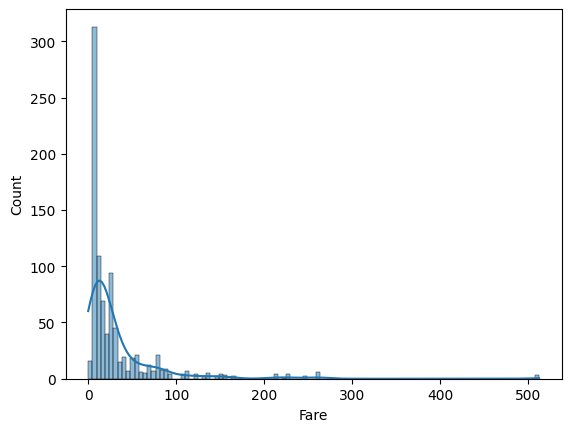

In [4]:
import seaborn as sns
sns.histplot(x=titanic_file['Fare'],kde=True)

Missing  values present?

In [5]:
(titanic_file.isnull().sum()/891)*100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In [6]:
#are there any rubbish columns to remove?
#dropping column axis=1, row axis=0
titanic_file=titanic_file.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
titanic_file.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,male,22.0,1,0,7.2500,NaN,S
1,1,1,female,38.0,1,0,71.2833,C85,C
2,1,3,female,26.0,0,0,7.9250,NaN,S
3,1,1,female,35.0,1,0,53.1000,C123,S
4,0,3,male,35.0,0,0,8.0500,NaN,S


In [7]:
#rename column names
titanic_file=titanic_file.rename(columns={'Parch':'Parent_child'})

#if there were duplicate entries-
titanic_file=titanic_file.drop_duplicates()

Divide into numerical and categorical columns

In [8]:
#how many unique values in each column
titanic_file.nunique()

,0
Survived,2
Pclass,3
Sex,2
Age,88
SibSp,7
Parent_child,7
Fare,248
Cabin,147
Embarked,3


In [9]:
numerical_cols=["Age","SibSp","Parent_child","Fare"]
numeric_discrete=["SibSp","Parent_child"]
numeric_continuous=["Age","Fare"]
categorical_cols=["Embarked","Sex","Survived","Pclass","Cabin"]
#titanic_file[["Embarked","Sex","Survived","Pclass","Cabin"]]=titanic_file[["Embarked","Sex","Survived","Pclass","Cabin"]].astype("category")

In [10]:
titanic_file.dtypes

,0
Survived,int64
Pclass,int64
Sex,object
Age,float64
SibSp,int64
Parent_child,int64
Fare,float64
Cabin,object
Embarked,object


Plot stacked plot, box plot/violin plot for each column with Target

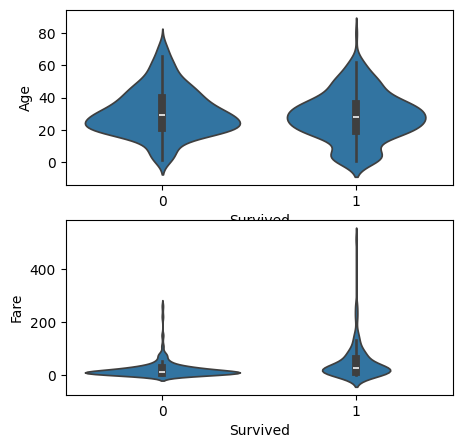

In [11]:
#categorical (survived) vs numeric continuous - violin plot, point plot
import matplotlib.pyplot as plt
import seaborn as sns
fig,axes=plt.subplots(2,1,figsize=(5,5))
#axes=axes.flatten()
for i,col in enumerate(numeric_continuous):
  sns.violinplot(x="Survived",y=col,data=titanic_file,ax=axes[i])


Seems like overall population had maximum people in age group 20-30 , therefore both survived and missing had maximum numbers in that age group

Lowest Fare-maximum deaths

Highest fare- fall under survived

Survived people had different range of Fare. There were survivors in low fare section too but not that dominant as seen in deaths

Fare could have extreme outliers - check how many are there

<Axes: ylabel='Fare'>

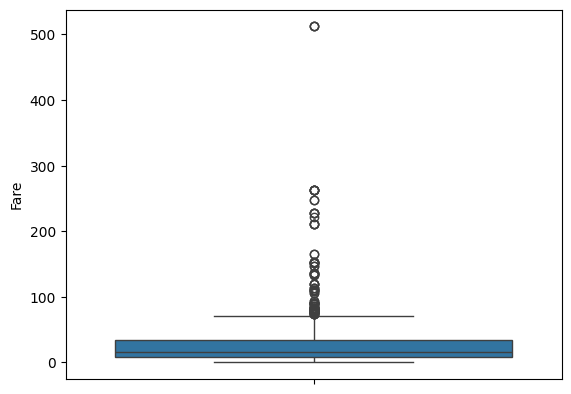

In [12]:
sns.boxplot(titanic_file["Fare"])

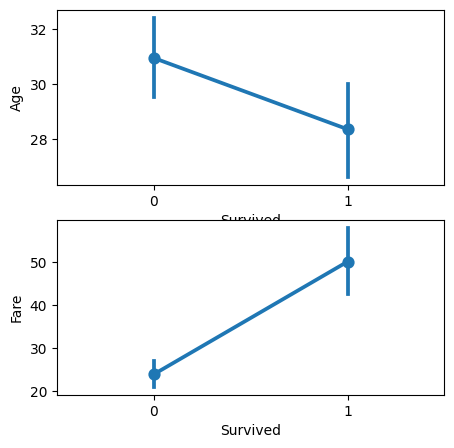

In [13]:
fig,axes=plt.subplots(2,1,figsize=(5,5))
#axes=axes.flatten()
for i,col in enumerate(numeric_continuous):
  sns.pointplot(x="Survived",y=col,data=titanic_file,ax=axes[i])

Age doesn't seem to have much relation with survival rate but Fare seems to have a bit of relation.

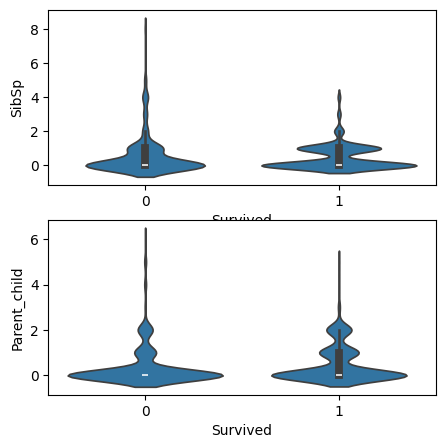

In [14]:
#categorical (survived) vs numeric discrete -violin plot
fig,axes=plt.subplots(2,1,figsize=(5,5))
#axes=axes.flatten()
for i,col in enumerate(numeric_discrete):
  sns.violinplot(x="Survived",y=col,data=titanic_file,ax=axes[i])

Most passengers were solo as both 0,1 have high concentration around 0 for parent_child and SibSp.

Passengers with large family were less. Appearing in death category more but could that be because of lesser numbers in terms of population

People with 1 sibling had higher survivors.

Clear indication can't be found in family size, survival rate

In [15]:
for col in categorical_cols:
  cross_tab=pd.crosstab(titanic_file['Survived'],titanic_file[col])
  print(cross_tab)

Embarked   C   Q    S
Survived             
0         65  39  357
1         90  20  211
Sex       female  male
Survived              
0             76   385
1            217   106
Survived    0    1
Survived          
0         461    0
1           0  323
Pclass      1   2    3
Survived              
0          79  81  301
1         135  84  104
Cabin     A10  A14  A16  A19  A20  A23  A24  A26  A31  A32  ...  E8  F E69  \
Survived                                                    ...              
0           1    1    0    1    0    0    1    0    0    1  ...   0      0   
1           0    0    1    0    1    1    0    1    1    0  ...   2      1   

Cabin     F G63  F G73  F2  F33  F38  F4  G6  T  
Survived                                         
0             1      2   1    0    1   0   2  1  
1             0      0   2    3    0   2   2  0  

[2 rows x 147 columns]


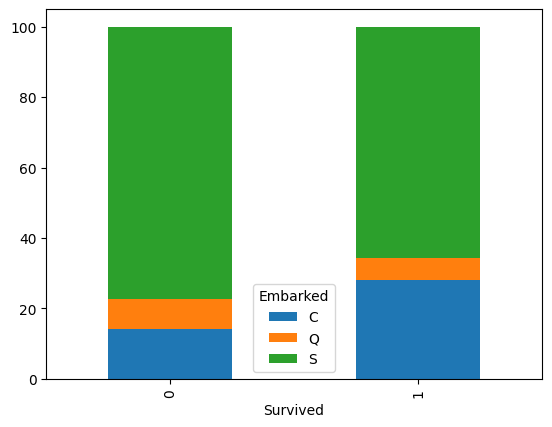

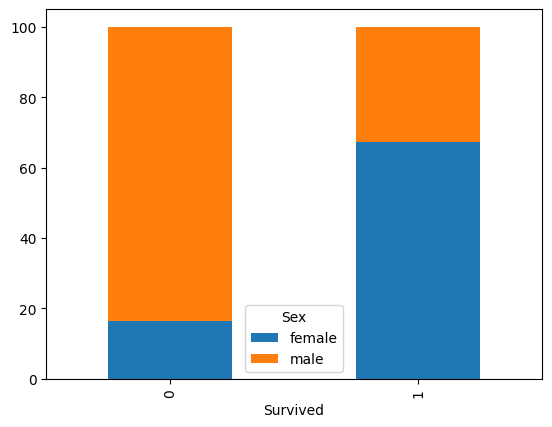

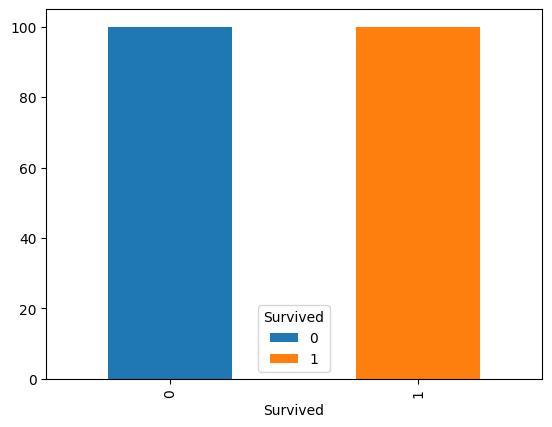

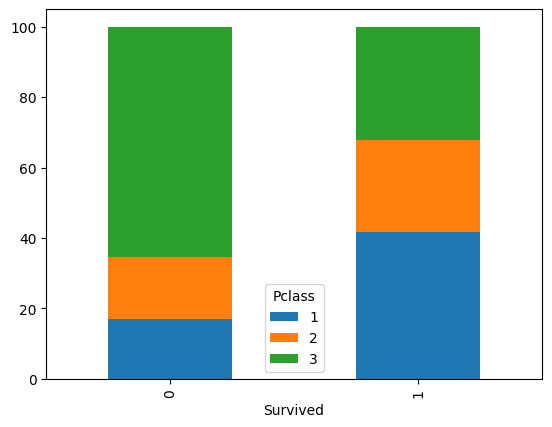

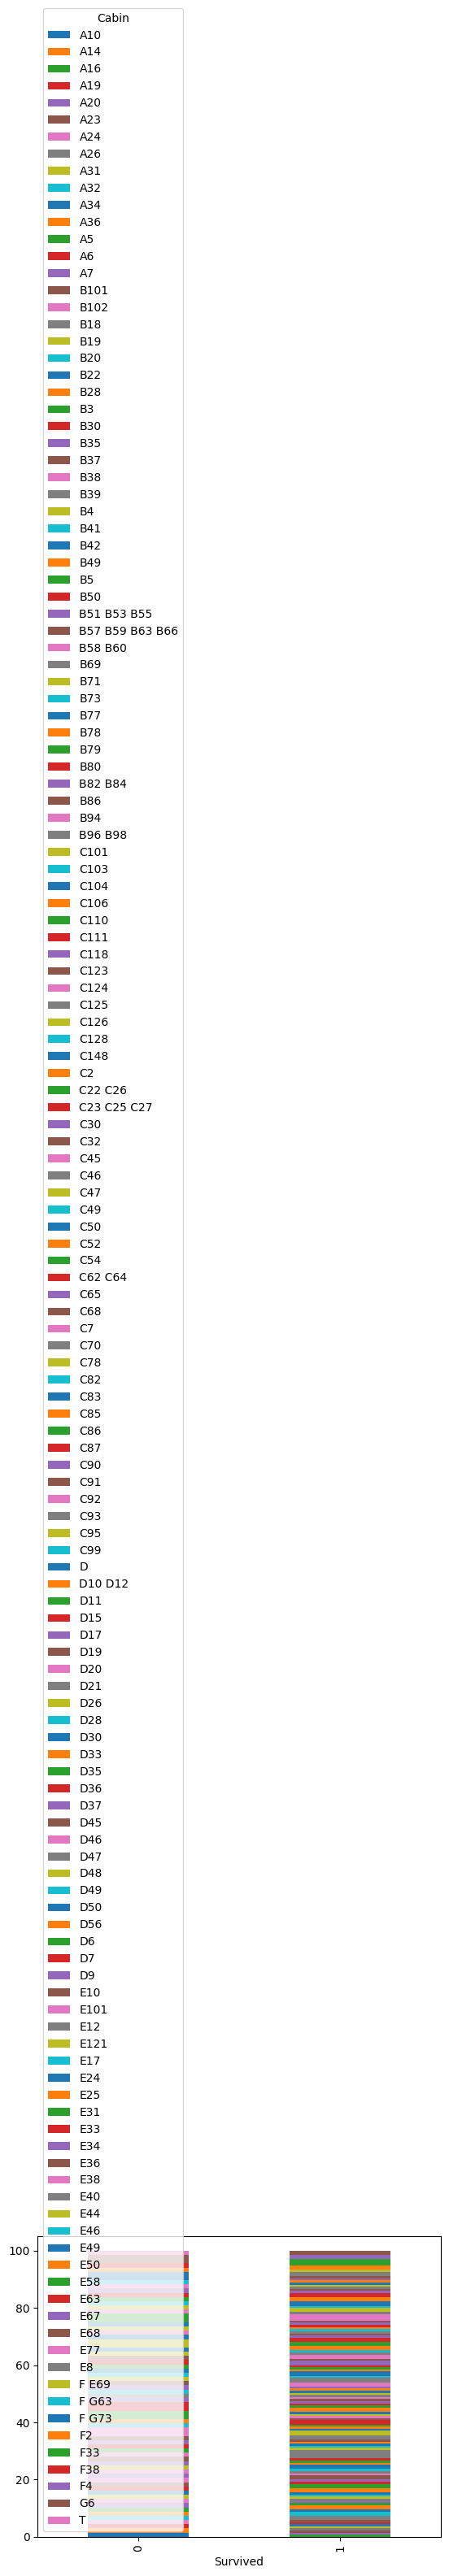

In [16]:
#categorical vs categorical -stacked bar chart
#fig,axes=plt.subplots(2,1,figsize=(5,5))
for col in categorical_cols:
    cross_tab=pd.crosstab(titanic_file['Survived'],titanic_file[col], normalize='index')*100 #index gives row %
    #print(cross_tab)
    cross_tab.plot(kind='bar',stacked=True)
    print()

The above charts with proportion inverted like in sex vs survived

and in Pclass vs survived

Females have better survival chances

Pclass 1 has better survival chances

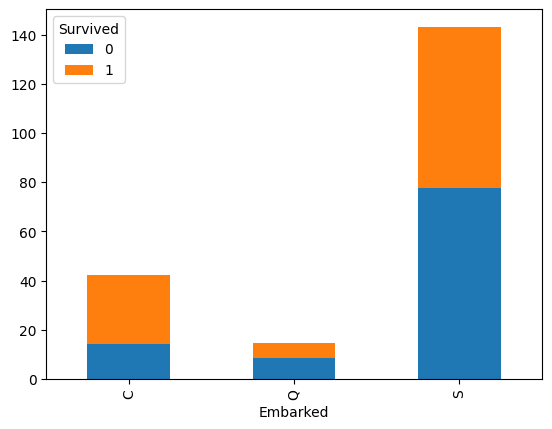

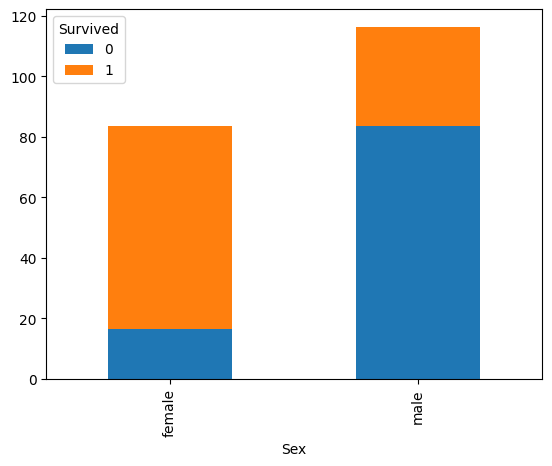

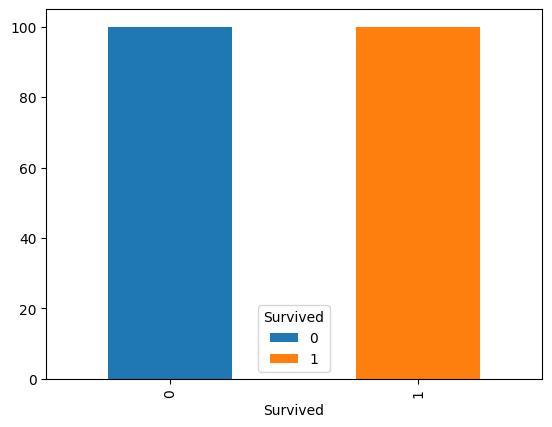

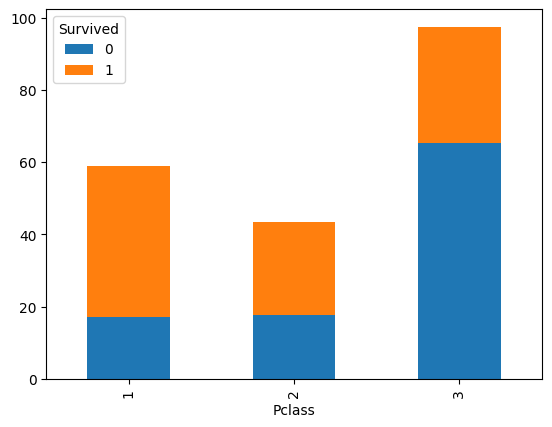

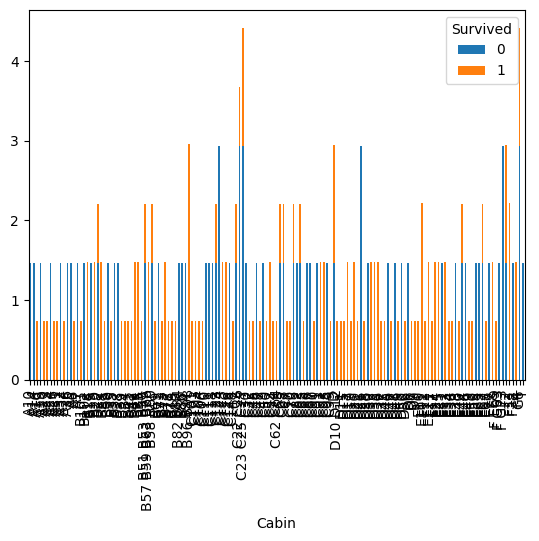

In [17]:
for col in categorical_cols:
    cross_tab=pd.crosstab(titanic_file[col],titanic_file['Survived'], normalize='columns')*100 #column %
    #print(cross_tab)
    cross_tab.plot(kind='bar',stacked=True)
    print()

Again confirmed that males have higher death rate

Pclass 3 has high death rate while class 1 has high survival rate

S embarked seems to have less chance or survival - could it because of some other factor?

In [18]:
#crosstab of Embarked vs PClass
cross_tab=pd.crosstab(titanic_file['Embarked'],titanic_file['Pclass'],normalize='index')
print(cross_tab)

Pclass           1         2         3
Embarked                              
C         0.535484  0.109677  0.354839
Q         0.033898  0.050847  0.915254
S         0.223592  0.255282  0.521127


In [19]:
cross_tab=pd.crosstab(titanic_file['Embarked'],titanic_file['Sex'], normalize='index')
print(cross_tab)

Sex         female      male
Embarked                    
C         0.458065  0.541935
Q         0.440678  0.559322
S         0.341549  0.658451


Since embarked S has maximum population and has higher ratio of males, death rate could have been higher

Similarly for pclass- S,Q have maximum people in class 3. Could be the reason for more deaths

Do any of these features have correlation among themselves?

 chi square for categorical vs categorical,

 categorical vs discrete - using violin plot and groupby categorical

 corr() for continuous variables vs continuous (check for normality first else use Spearman's correlation)

 categorical vs continuous

 discrete vs continuous

 discrete vs discrete

After performing bivariate analysis, convert all data to numerical. Also will handle missing data after bivariate analysis


In [20]:
#create new column for cabin missing or not
titanic_file['Cabin_not_allotment'] = titanic_file['Cabin'].isnull().astype("category")
categorical_cols.append('Cabin_not_allotment')

In [21]:
titanic_file.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parent_child', 'Fare',
       'Cabin', 'Embarked', 'Cabin_not_allotment'],
      dtype='object')

        count      mean       std  min  25%  50%  75%  max
Pclass                                                    
1       214.0  0.359813  0.696384  0.0  0.0  0.0  0.0  4.0
2       165.0  0.424242  0.716968  0.0  0.0  0.0  1.0  3.0
3       405.0  0.441975  0.943826  0.0  0.0  0.0  0.0  6.0


<Axes: xlabel='Pclass', ylabel='Parent_child'>

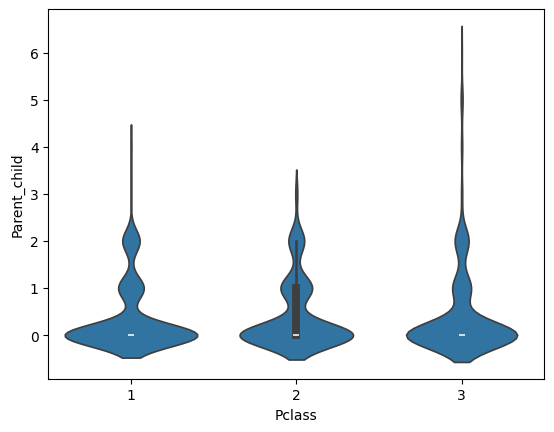

In [22]:
#numeric discrete vs categorical - parent_child ,SibSp vs Pclass,Embarked, Cabin_not_allotment,
print(titanic_file.groupby(['Pclass'])['Parent_child'].describe())
sns.violinplot(x="Pclass",y="Parent_child",data=titanic_file)

doesn't have significant difference in Pclass with children count.

        count      mean       std  min  25%  50%  75%  max
Pclass                                                    
1       214.0  0.420561  0.613424  0.0  0.0  0.0  1.0  3.0
2       165.0  0.436364  0.617735  0.0  0.0  0.0  1.0  3.0
3       405.0  0.612346  1.230932  0.0  0.0  0.0  1.0  8.0


<Axes: xlabel='Pclass', ylabel='SibSp'>

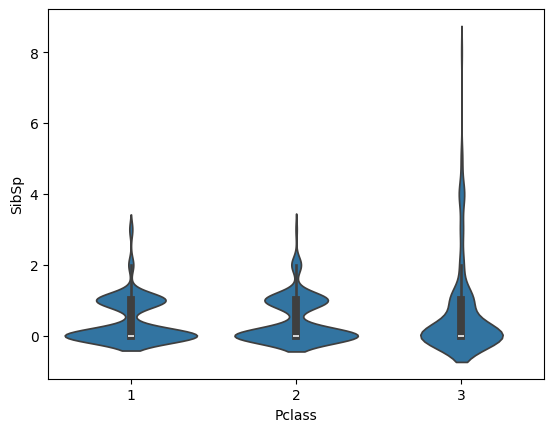

In [23]:
print(titanic_file.groupby(['Pclass'])['SibSp'].describe())
sns.violinplot(x="Pclass",y="SibSp",data=titanic_file)

Larger families are more in class 3.
While most passengers were travelling solo or as a couple

          count      mean       std  min  25%  50%  75%  max
Embarked                                                    
C         155.0  0.380645  0.676805  0.0  0.0  0.0  1.0  3.0
Q          59.0  0.220339  0.744353  0.0  0.0  0.0  0.0  5.0
S         568.0  0.447183  0.883331  0.0  0.0  0.0  1.0  6.0


<Axes: xlabel='Embarked', ylabel='Parent_child'>

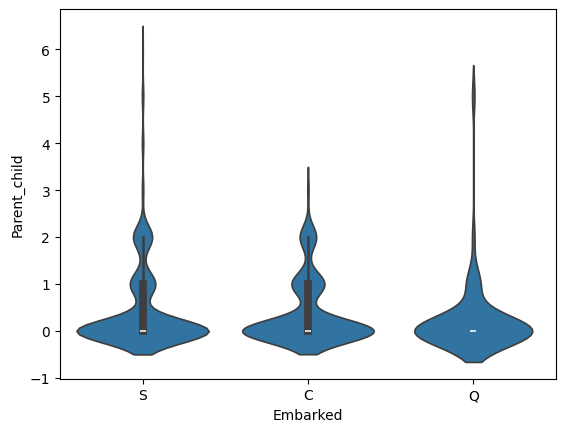

In [24]:
print(titanic_file.groupby(['Embarked'])['Parent_child'].describe())
sns.violinplot(x="Embarked",y="Parent_child",data=titanic_file)

          count      mean       std  min  25%  50%  75%  max
Embarked                                                    
C         155.0  0.400000  0.553619  0.0  0.0  0.0  1.0  2.0
Q          59.0  0.508475  1.088702  0.0  0.0  0.0  0.5  4.0
S         568.0  0.559859  1.064055  0.0  0.0  0.0  1.0  8.0


<Axes: xlabel='Embarked', ylabel='SibSp'>

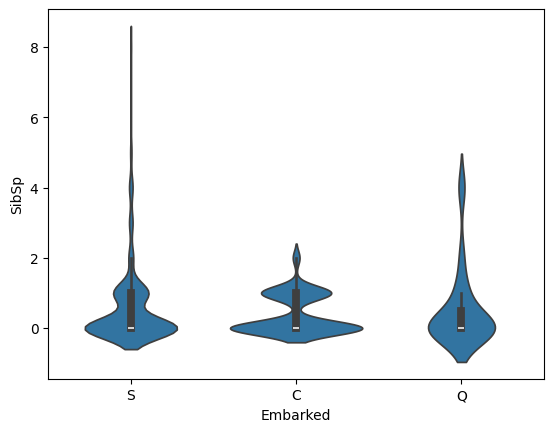

In [25]:
print(titanic_file.groupby(['Embarked'])['SibSp'].describe())
sns.violinplot(x="Embarked",y="SibSp",data=titanic_file)

S, Q had large families more than C though majority of them were solo/couple in all three start points

                     count      mean       std  min  25%  50%  75%  max
Cabin_not_allotment                                                    
False                203.0  0.438424  0.731133  0.0  0.0  0.0  1.0  4.0
True                 581.0  0.407917  0.871309  0.0  0.0  0.0  0.0  6.0


/tmp/ipython-input-2859558465.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(titanic_file.groupby(['Cabin_not_allotment'])['Parent_child'].describe())


<Axes: xlabel='Cabin_not_allotment', ylabel='Parent_child'>

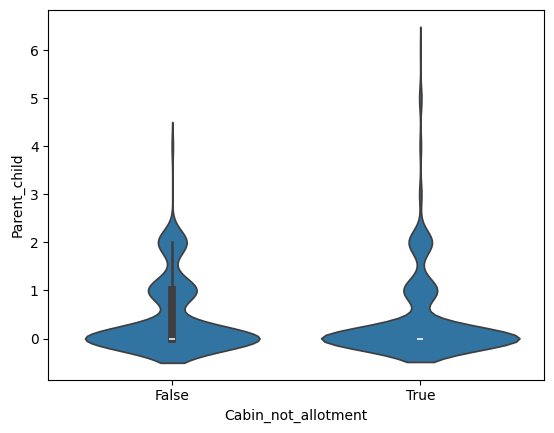

In [26]:
print(titanic_file.groupby(['Cabin_not_allotment'])['Parent_child'].describe())
sns.violinplot(x="Cabin_not_allotment",y="Parent_child",data=titanic_file)

/tmp/ipython-input-4204096098.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(titanic_file.groupby(['Cabin_not_allotment'])['SibSp'].describe())


                     count      mean       std  min  25%  50%  75%  max
Cabin_not_allotment                                                    
False                203.0  0.443350  0.629704  0.0  0.0  0.0  1.0  3.0
True                 581.0  0.550775  1.082583  0.0  0.0  0.0  1.0  8.0


<Axes: xlabel='Cabin_not_allotment', ylabel='SibSp'>

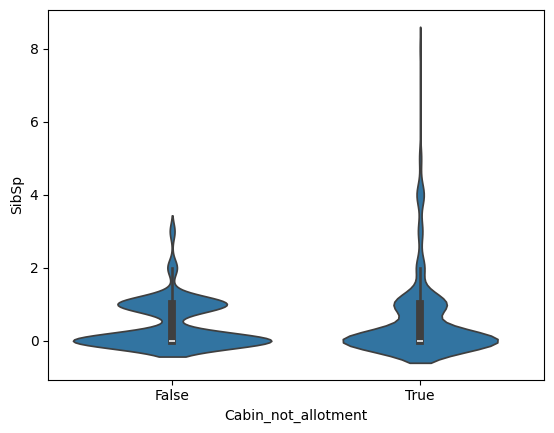

In [27]:
print(titanic_file.groupby(['Cabin_not_allotment'])['SibSp'].describe())
sns.violinplot(x="Cabin_not_allotment",y="SibSp",data=titanic_file)

No clear relationship between family size & cabin
Extremely large family (few count) did not have cabin alloted.

<Axes: xlabel='Parent_child', ylabel='SibSp'>

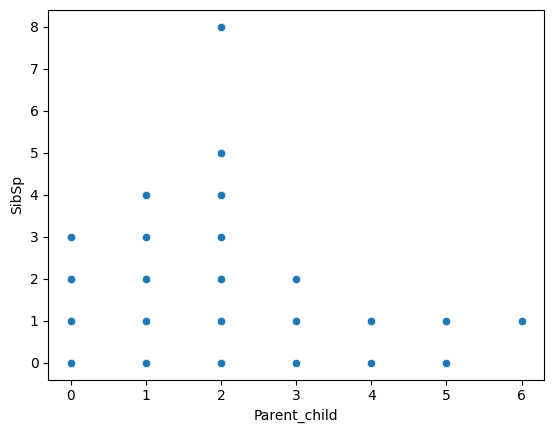

In [28]:
#numeric discrete vs numeric discrete - parent_child vs SibSp
sns.scatterplot(x="Parent_child",y="SibSp",data=titanic_file)

Parent_child : count of parent & children with a passenger
SibSp: count of siblings and spouse with a passenger
Directly taking sum of the two values doesn't give family size. Proportion could be similar or suggestive i.e. bigger number of either of the two variables indicate large family travelling together

In [29]:

#categorical vs categorical
#trying with nested list by adding if claus
category_comb_list=[]

for i in categorical_cols:
    for j in categorical_cols:
        if (i!=j) & ([i,j] not in category_comb_list) & ([j,i] not in category_comb_list):
            category_comb_list.append([i,j])

category_comb_list

from scipy.stats import chi2_contingency

for i in category_comb_list:
    contingency= pd.crosstab(titanic_file[i[0]], titanic_file[i[1]])
    chi2,p,dof,expected=chi2_contingency(contingency)

    if p < 0.05:
        print(f"{i[0]}, {i[1]} , {p}: Reject null - variables are dependent")
    else:
        print(f"{i[0]}, {i[1]} : No relationship between variables")

Embarked, Sex , 0.01530653077730579: Reject null - variables are dependent
Embarked, Survived , 8.444573962288354e-06: Reject null - variables are dependent
Embarked, Pclass , 2.388583733123591e-21: Reject null - variables are dependent
Embarked, Cabin , 0.002500405440838945: Reject null - variables are dependent
Embarked, Cabin_not_allotment , 1.5921393759245646e-09: Reject null - variables are dependent
Sex, Survived , 8.383408590582411e-47: Reject null - variables are dependent
Sex, Pclass , 0.001524249529225826: Reject null - variables are dependent
Sex, Cabin : No relationship between variables
Sex, Cabin_not_allotment , 0.0009369638030959552: Reject null - variables are dependent
Survived, Pclass , 4.7191799786773705e-20: Reject null - variables are dependent
Survived, Cabin : No relationship between variables
Survived, Cabin_not_allotment , 3.5809573720191066e-17: Reject null - variables are dependent
Pclass, Cabin , 1.1141610518683562e-05: Reject null - variables are dependent


In [30]:
#for numeric continuous vs numeric continuous
#since we know Fare is skewed, normal distribution isn't followed, applying spearman
titanic_file[numeric_continuous].corr(method='spearman')

,Age,Fare
Age,1.00000,0.13032
Fare,0.13032,1.00000


Define function to test ANOVA assumption- normal distribution of dependent variable in each group ofthe categorical independent variable - shapiro test

Shapiro test is for checking normality if the dependent variable is continuous variable.

We could use Kruskal test for continuous vs categorical (already tested in earlier notebook and found that data was not normally distributed within groups)

But I'm proceeding with graphical methods for convenience. Providing sample for Shapiro test and Kruskal for reference

Group 3: Shapiro-Wilk test =  nan, pvalue= nan
Data in group "3" not normally distributed
Group 1: Shapiro-Wilk test =  nan, pvalue= nan
Data in group "1" not normally distributed
Group 2: Shapiro-Wilk test =  nan, pvalue= nan
Data in group "2" not normally distributed


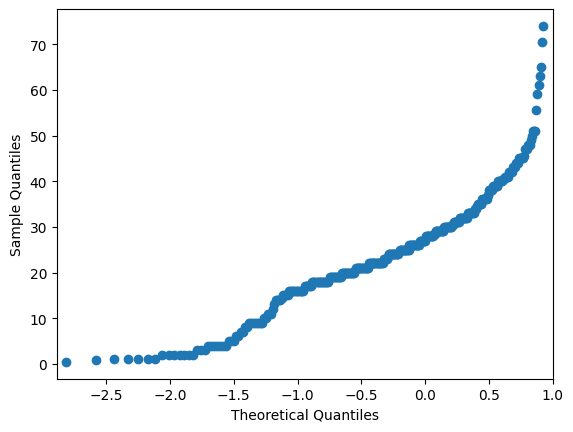

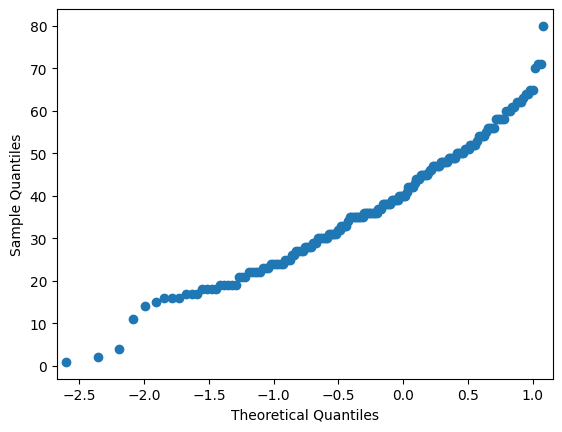

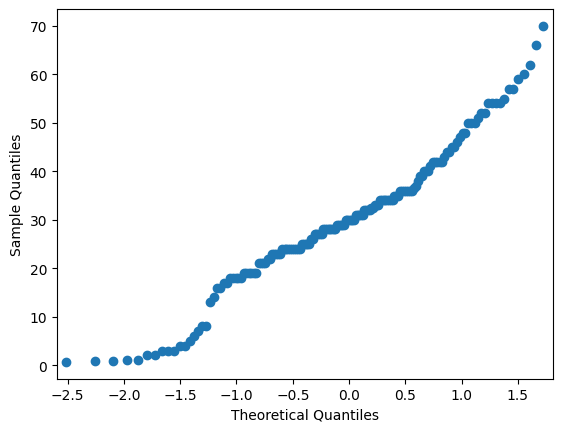

In [31]:
from scipy.stats import shapiro
import statsmodels.api as sm

def check_normality(dataframe, group_col, value_col):
    groups = dataframe[group_col].unique() #to get groups in the categorical column. In this case- gives 0,1 Male Female
    for group in groups:
        group_data=dataframe[dataframe[group_col]==group][value_col] #extracts Age values associated with each group
        stat, p_value = shapiro(group_data)
        print(f'Group {group}: Shapiro-Wilk test = {stat: .4f}, pvalue= {p_value:.4f}')
        if p_value > 0.05:
            print(f'Data in group "{group}" seems to be normally distributed')
        else:
            print(f'Data in group "{group}" not normally distributed')

        #Q-Q plot for visual check
        sm.qqplot(group_data,line='s')
        #plt.show()
check_normality(titanic_file, "Pclass", "Age")

t-test is easier to be used for categorical column with 2 groups but ANOVA can be used too.

Now if distribution isn't normal within groups, use Krusal wallis if there are >=3 groups in categorical column if 2 groups -use Mann-Whitney U test - like Age vs Sex

Assumptions of Kruskal Wallis test: Independent Groups: You are comparing distinct groups of subjects (e.g., comparing three different teaching methods where different students are in each group). Dependent Variable is Ordinal or Continuous: The data you are measuring can be ranked (ordinal, like Likert scale ratings) or is a continuous measure (interval/ratio, like time or scores). Independent Observations: What happens to one subject or observation does not affect another subject or observation. Similar Distribution Shapes (for Median Comparison): If your goal is to say something about the medians of the groups, the underlying data distributions for each group should look similar in shape. Random Sampling or Assignment: The groups or samples were selected randomly to ensure they are representative of their respective populations.

In [32]:
#kruskal test for Age vs Pclass relationship
from scipy import stats
#need to eliminate missing records in Age for Kruskal to work
data_group1 = titanic_file[titanic_file["Pclass"]==1]["Age"].dropna().values
data_group2 = titanic_file[titanic_file["Pclass"]==2]["Age"].dropna().values
data_group3 = titanic_file[titanic_file["Pclass"]==3]["Age"].dropna().values

#Conduct the Kruskal-Wallis Test
statistic,p = stats.kruskal(data_group1, data_group2, data_group3)
if p < 0.05:
  print("There is relation between Pclass and Age")

There is relation between Pclass and Age


In [33]:
categorical_cols

['Embarked', 'Sex', 'Survived', 'Pclass', 'Cabin', 'Cabin_not_allotment']

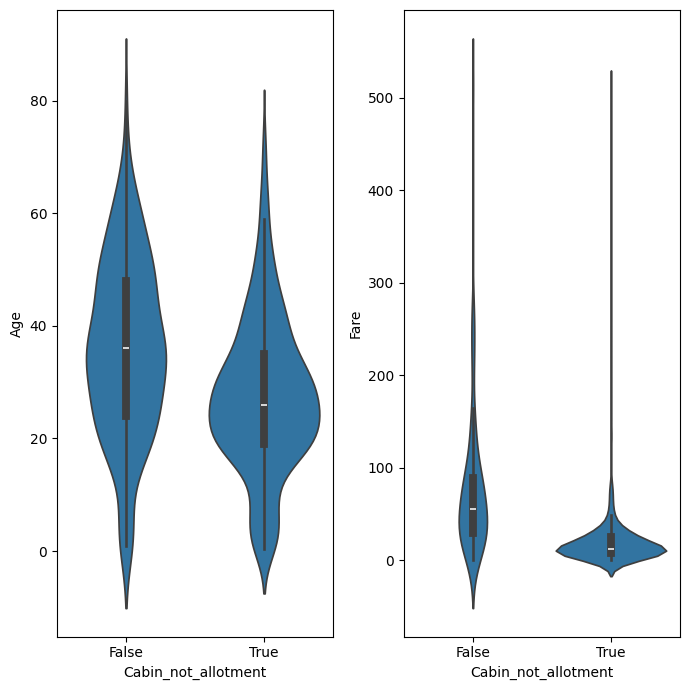

In [34]:
#categorical vs continuous
fig,axes=plt.subplots(1,2,figsize=(7,7))
#axes=axes.flatten()
for i,col in enumerate(numeric_continuous):
  sns.violinplot(x="Cabin_not_allotment",y=col,data=titanic_file,ax=axes[i])
plt.tight_layout()

Cabin allotment is clearly related to Fare. No cabin-cheap

Cabin allotment is kind of related to Age distribution -roughly 18-35 age group don't have cabin. 23-45 have cabins.

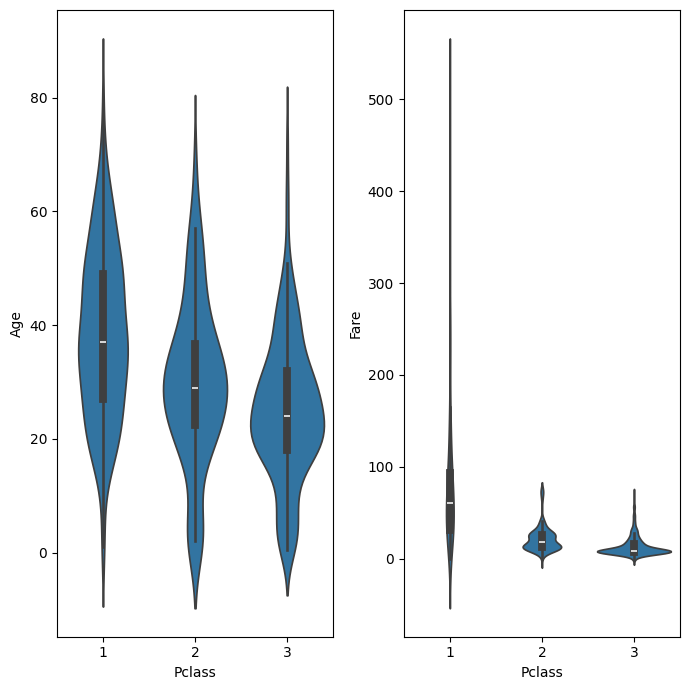

In [35]:
#categorical vs continuous
fig,axes=plt.subplots(1,2,figsize=(7,7))
#axes=axes.flatten()
for i,col in enumerate(numeric_continuous):
  sns.violinplot(x="Pclass",y=col,data=titanic_file,ax=axes[i])
plt.tight_layout()

Class and Fare have a clear relation.
Class1 has high Fare, followed by class 2 then by class3

Class and Age also seem to be fairly related. Middle age members more in class1 and youngsters ones more in class 3

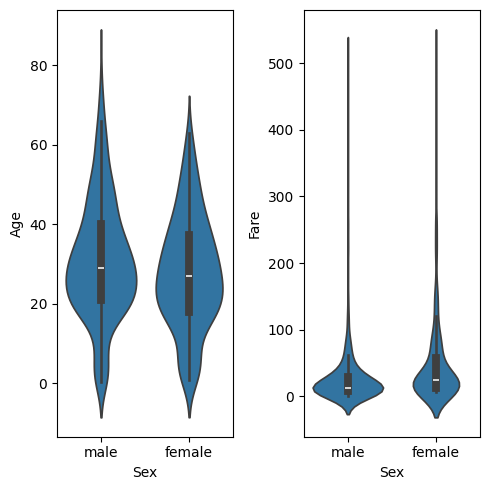

In [36]:
#categorical vs continuous
fig,axes=plt.subplots(1,2,figsize=(5,5))
#axes=axes.flatten()
for i,col in enumerate(numeric_continuous):
  sns.violinplot(x="Sex",y=col,data=titanic_file,ax=axes[i])
plt.tight_layout()

Not much could be said about gender and relation with age, Fare.

Some oldies are men

low Fare paid by male members more

A few females paid high fare

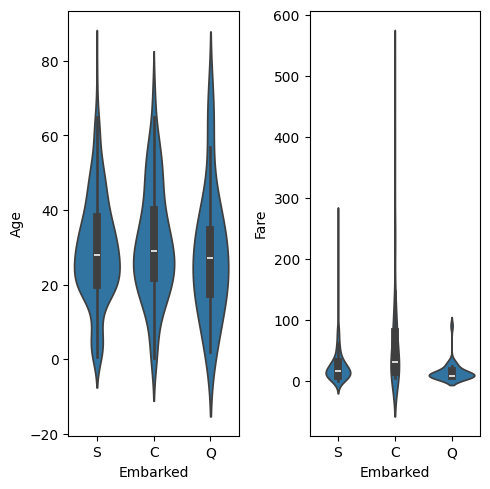

In [37]:
#categorical vs continuous
fig,axes=plt.subplots(1,2,figsize=(5,5))
#axes=axes.flatten()
for i,col in enumerate(numeric_continuous):
  sns.violinplot(x="Embarked",y=col,data=titanic_file,ax=axes[i])
plt.tight_layout()

S, C have higher fare members (not a lot of people, well population of high fare passengers is less overall)

<Axes: xlabel='Parent_child', ylabel='Age'>

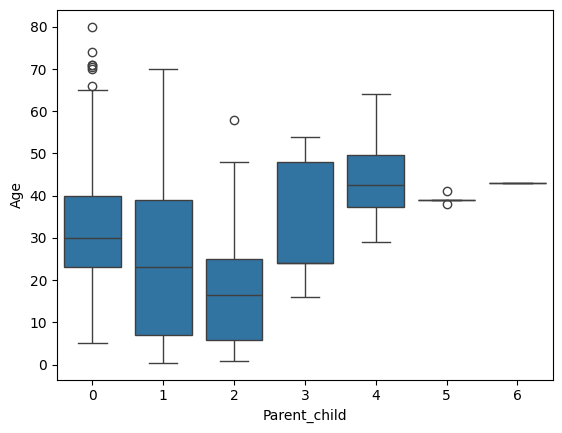

In [38]:
sns.boxplot(y=titanic_file["Age"],x=titanic_file["Parent_child"])

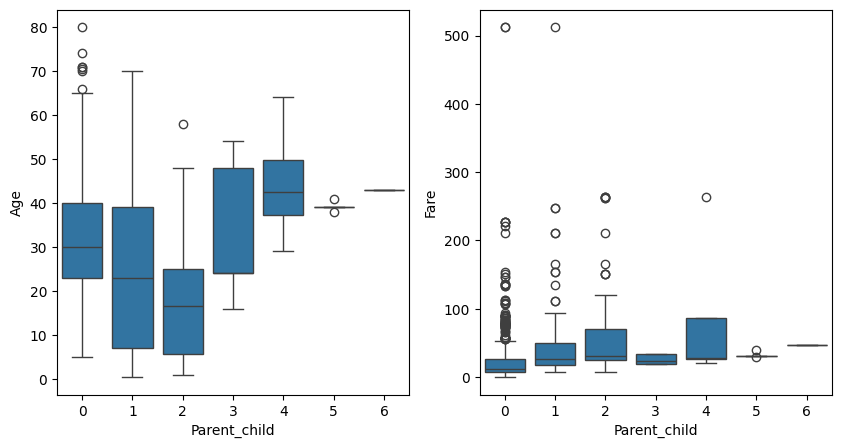

In [39]:
#numeric continuous vs numeric discrete

ax,fig=plt.subplots(1,2,figsize=(10,5))
for i,col in enumerate(numeric_continuous):
  sns.boxplot(y=titanic_file[col],x=titanic_file["Parent_child"],ax=fig[i])
plt.show()


Not a linear relation or some clear pattern between Age and parent child but they are not really independent of each other.

Oldies mostly came alone

Parent_child upto 2, average age keeps dropping - maybe because of young children

Parent_child 3 onwards , average age increases maybe because children are teen/adults

Solo travelers have different range of Fare. Fammilies >=5 booked cheap tickets (economical for large family).

Other family sizes in between have different price range

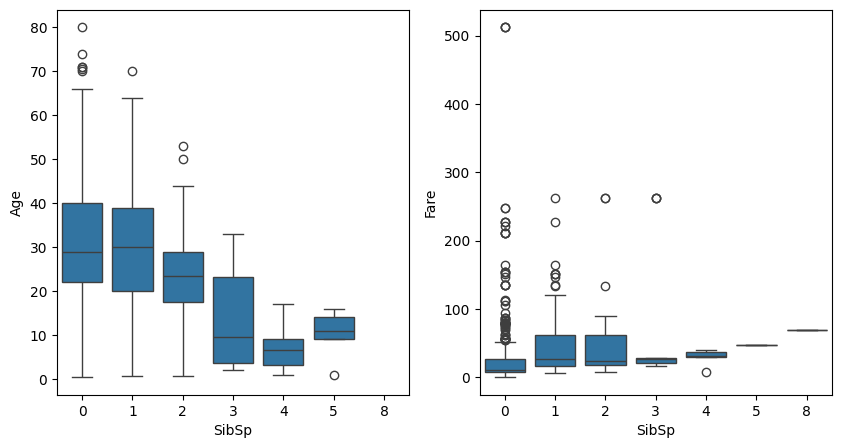

In [40]:
ax,fig=plt.subplots(1,2,figsize=(10,5))
for i,col in enumerate(numeric_continuous):
  sns.boxplot(y=titanic_file[col],x=titanic_file["SibSp"],ax=fig[i])
plt.show()

In summary- none of numerical columns are interdependent or dependent with categorical columns but some categorical columns seem to have relationship amongst thems.

Class has relation with Age, Fare- try logistic regression with and without Fare column

What to do with Age, Fare relation with Family size?

We've already established that Survived is related to Pclass, Sex, Cabin_not_allotment so keeping these three. Remove embarked and Cabin for logistic regression as they have relation with other categorical columns(Embarked) or do not have relation with Survived (Cabin)

For RandomForest, I would like to keep these two and see the impact

Cabin and Age need to be addressed as they have a lot of missing data

Handling missing data - first find if missingness has a meaning.

Are the missing values related to the target?

Are the missing values related to any other column/feature?


In [41]:
#checking if cabin missing has relation with Survived
titanic_file.groupby(['Cabin_not_allotment'])['Survived'].mean()



/tmp/ipython-input-3685743892.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  titanic_file.groupby(['Cabin_not_allotment'])['Survived'].mean()


,Survived
Cabin_not_allotment,
False,0.665025
True,0.323580


IF cabin not alloted, chances of survival decreased

In [42]:
#checking if missing Age has connection with Survived
titanic_file.Age.isnull().groupby(titanic_file.Survived).mean()

,Age
Survived,
0,0.145336
1,0.120743


Not much difference in missing Age group for survived category

In [43]:
titanic_file.info()

<class 'pandas.core.frame.DataFrame'>
Index: 784 entries, 0 to 890
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Survived             784 non-null    int64   
 1   Pclass               784 non-null    int64   
 2   Sex                  784 non-null    object  
 3   Age                  678 non-null    float64 
 4   SibSp                784 non-null    int64   
 5   Parent_child         784 non-null    int64   
 6   Fare                 784 non-null    float64 
 7   Cabin                203 non-null    object  
 8   Embarked             782 non-null    object  
 9   Cabin_not_allotment  784 non-null    category
dtypes: category(1), float64(2), int64(4), object(3)
memory usage: 62.1+ KB


In [44]:
#since encoding is needed only forlogistic regression not for Random forest, removing Embarked, Cabin from here

titanic_file_encoded=titanic_file[['Survived','Age','Fare','Cabin_not_allotment','Sex','Pclass','Parent_child','SibSp']]
#titanic_file_encoded=pd.get_dummies(titanic_file_encoded, columns=one_hot_encoding,dtype=int)
titanic_file_encoded['Sex']=titanic_file_encoded['Sex'].replace({'male':1,'female':0})
titanic_file_encoded.Cabin_not_allotment=titanic_file_encoded.Cabin_not_allotment.astype(int)
titanic_file_encoded.head()

/tmp/ipython-input-2205366037.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_file_encoded['Sex']=titanic_file_encoded['Sex'].replace({'male':1,'female':0})
/tmp/ipython-input-2205366037.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  titanic_file_encoded['Sex']=titanic_file_encoded['Sex'].replace({'male':1,'female':0})
/tmp/ipython-input-2205366037.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

,Survived,Age,Fare,Cabin_not_allotment,Sex,Pclass,Parent_child,SibSp
0,0,22.0,7.2500,1,1,3,0,1
1,1,38.0,71.2833,0,0,1,0,1
2,1,26.0,7.9250,1,0,3,0,0
3,1,35.0,53.1000,0,0,1,0,1
4,0,35.0,8.0500,1,1,3,0,0


Deal with missing values first and then check for multi-collinearity (OLS can;t handle missing values)

Don't want to impute using mean. Let's check what's the difference with all 3 methods of imputation

1) using mean imputation

2) K-NN imputation- Computing intensive. Suitable for small-medium dataset. Like Titanic. Maybe we could use cross validation to find optimal k value but keeping it simple here. If performance is not good for final classification, then revisit this point.

3) MICE - can be used for MAR only. Computing intensive. Difficult for large dataset. Any regression model could be used.  Random Forest could give best results



In [45]:
#KNN imputation
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split

def knn_imputation(df,k):
  #split into train test data for classification model for Survived
  #we will test after imputation- we'll predict if passenger survived and check for accuracy of this imputed dataset
  X_train,X_test,y_train,y_test=train_test_split(df.drop(['Survived'],axis=1,inplace=False),titanic_file_encoded['Survived'],test_size=0.2,random_state=42)

  imputer=KNNImputer(n_neighbors=k,weights='distance',metric='nan_euclidean')
  #just don't take average of neighbours. Use their distance as weights

  #had there been other columns with missing data, those would also have been filled in one go
  #we will use train data to learn for KNN imputation and apply the same on test data without fitting
  X_train_knnimpute=pd.DataFrame(imputer.fit_transform(X_train),columns=X_train.columns)
  X_test_knnimpute=pd.DataFrame(imputer.transform(X_test),columns=X_test.columns)

  #apply logistic regression or any model to test accuracy
  #fit on train data
  from sklearn.linear_model import LogisticRegression
  log_reg=LogisticRegression(random_state=42) #liblinear uses weights to optimize loss function
  log_reg.fit(X_train_knnimpute,y_train)
  #predict on test data
  y_test_pred=log_reg.predict(X_test_knnimpute)
  #check accuracy
  from sklearn.metrics import accuracy_score
  #since survived and death rate both types are fairly available in dataset, using accuracy as metric
  print(f"accuracy with k value {k}",accuracy_score(y_test,y_test_pred) )

#now I'll update k value and check accuracy score again.
knn_imputation(titanic_file_encoded,5)
knn_imputation(titanic_file_encoded,2)
knn_imputation(titanic_file_encoded,100)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


accuracy with k value 5 0.7898089171974523
accuracy with k value 2 0.7898089171974523
accuracy with k value 100 0.7834394904458599


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

So we can conclude that k=2 is the most optimal value for performing KNN imputation. Will apply this for entire titanic_file_encoded

In [46]:
imputer=KNNImputer(n_neighbors=2,weights='distance',metric='nan_euclidean')
titanic_file_encoded=pd.DataFrame(imputer.fit_transform(titanic_file_encoded),columns=titanic_file_encoded.columns)

In [47]:
titanic_file_encoded.isnull().sum()

,0
Survived,0
Age,0
Fare,0
Cabin_not_allotment,0
Sex,0
Pclass,0
Parent_child,0
SibSp,0


Check if variables have collinearity/multi colinearity - VIF - could be possible that multiple independent variable together affect another independent variable

Ensure to have to convert to numerical data first to be able to apply VIF

Will have to deal with missing values too for VIF testing.

VIF will help in feature selection further

In [48]:


#VIF test for multicollinearity
#separate target and independent variables
X=titanic_file_encoded.drop(['Survived'],axis=1, inplace=False)
y=titanic_file_encoded['Survived']

from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                          for i in range(len(X.columns))]
vif_data

,feature,VIF
0,Age,3.820036
1,Fare,1.703502
2,Cabin_not_allotment,8.267314
3,Sex,2.901052
4,Pclass,11.443020
5,Parent_child,1.583105
6,SibSp,1.591224


Pclass, Cabin_not_allotment ave high multicollinearity with other independent variables

Maybe because Pclass and Cabin_not_allotment both could be explained by Fare?

Keeping Pclass, Cabin_not_allotment for now. If logistic regression gives poor results  then will revisit this -remove Pclass and Cabin_not_allotment or remove Fare and see the impact

How to deal with outliers? Should I just run the logistic regression first to get a baseline and then deal with outliers? Random forest won't get affected by outliers as such

Scale data to reduce unfair impact of Fare high scale

In [49]:
#since we have outliers in the distribution, choosing robust scale
from sklearn.preprocessing import RobustScaler
def robust_scale_Data(df):
  scaler=RobustScaler()
  scaled_data=scaler.fit_transform(df)
  return scaled_data

In [50]:
titanic_file_encoded_scaled=robust_scale_Data(titanic_file_encoded)
titanic_file_encoded_scaled=pd.DataFrame(titanic_file_encoded_scaled,columns=titanic_file_encoded.columns)
titanic_file_encoded_scaled.head()

,Survived,Age,Fare,Cabin_not_allotment,Sex,Pclass,Parent_child,SibSp
0,0.0,-0.370384,-0.331935,0.0,0.0,0.0,0.0,1.0
1,1.0,0.518505,2.125276,-1.0,-1.0,-1.0,0.0,1.0
2,1.0,-0.148162,-0.306032,0.0,-1.0,0.0,0.0,0.0
3,1.0,0.351838,1.427511,-1.0,-1.0,-1.0,0.0,1.0
4,0.0,0.351838,-0.301235,0.0,0.0,0.0,0.0,0.0


Import test data and perform same transformation done on train data so far i.e. how titanic_file_encoded was created followed by titanic_file_encoded_scaled

In [51]:
titanic_test=pd.read_csv("/content/train.csv")
#feature selection/engineering and encoding
titanic_test.rename(columns={'Parch':'Parent_child'},inplace=True)

titanic_test['Cabin_not_allotment'] = titanic_test['Cabin'].isnull().astype("category")
titanic_test['Sex']=titanic_test['Sex'].replace({'male':1,'female':0})
titanic_test=titanic_test[['Survived', 'Age', 'Fare', 'Cabin_not_allotment', 'Sex', 'Pclass',
       'Parent_child', 'SibSp']]
#titanic_test.drop(['PassengerId','Ticket','Cabin','Name','Embarked'],inplace=True,axis=1)


/tmp/ipython-input-1301508843.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  titanic_test['Sex']=titanic_test['Sex'].replace({'male':1,'female':0})


In [52]:
titanic_test.columns

Index(['Survived', 'Age', 'Fare', 'Cabin_not_allotment', 'Sex', 'Pclass',
       'Parent_child', 'SibSp'],
      dtype='object')

In [53]:
titanic_file_encoded.columns

Index(['Survived', 'Age', 'Fare', 'Cabin_not_allotment', 'Sex', 'Pclass',
       'Parent_child', 'SibSp'],
      dtype='object')

In [54]:
#imputing missing values in test data
#titanic_file_encoded.head()
titanic_test_encoded=pd.DataFrame(imputer.transform(titanic_test),columns=titanic_test.columns)

In [55]:
titanic_test_encoded.isnull().sum()

,0
Survived,0
Age,0
Fare,0
Cabin_not_allotment,0
Sex,0
Pclass,0
Parent_child,0
SibSp,0


In [56]:
#scaling test data
titanic_test_scaled=robust_scale_Data(titanic_test)
titanic_test_scaled=pd.DataFrame(titanic_file_encoded_scaled,columns=titanic_file_encoded.columns)
titanic_test_scaled.head()

,Survived,Age,Fare,Cabin_not_allotment,Sex,Pclass,Parent_child,SibSp
0,0.0,-0.370384,-0.331935,0.0,0.0,0.0,0.0,1.0
1,1.0,0.518505,2.125276,-1.0,-1.0,-1.0,0.0,1.0
2,1.0,-0.148162,-0.306032,0.0,-1.0,0.0,0.0,0.0
3,1.0,0.351838,1.427511,-1.0,-1.0,-1.0,0.0,1.0
4,0.0,0.351838,-0.301235,0.0,0.0,0.0,0.0,0.0


Applying logistic regression on train data

In [57]:
#round1 with Logistic regression.
#Checking without handling outliers & including Pclass,Fare,Cabin_not_allotment
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
def apply_logistic_regression(df_train, df_test):
  X_train=df_train.drop(['Survived'],axis=1,inplace=False)
  y_train=df_train['Survived']

  lr=LogisticRegression(solver="liblinear",random_state=42)
  lr.fit(X_train,y_train)
  X_test=df_test.drop(['Survived'],axis=1,inplace=False)
  y_test=df_test['Survived']
  y_pred=lr.predict(X_test)
  print("accuracy for test data ",accuracy_score(y_test,y_pred) )
apply_logistic_regression(titanic_file_encoded_scaled,titanic_test_scaled)

accuracy for test data  0.7857142857142857


Let's repeat logistic regression by modifying some features like Family size

Then remove Fare or Pclass and Cabin_allotment to see if anything improves

Deal with outliers -

Set cap limit

Then maybe bucket Fare and see if model improves

Bucket Age and see if model improves



In [58]:
#train dataset add family size feature, remove Parent_child, SibSp
titanic_train_data2=titanic_file_encoded.copy()
titanic_train_data2["Family_size"]=titanic_train_data2["Parent_child"]+titanic_train_data2["SibSp"]
titanic_train_data2=titanic_train_data2.drop(['Parent_child','SibSp'],axis=1,inplace=False)
columns_chosen=titanic_train_data2.columns
titanic_train_scaled_data2=robust_scale_Data(titanic_train_data2)
titanic_train_scaled_data2=pd.DataFrame(titanic_train_scaled_data2,columns=columns_chosen)
titanic_train_scaled_data2.head()

#do the same on test data

titanic_test_data2=titanic_test_encoded.copy()
titanic_test_data2["Family_size"]=titanic_test_data2["Parent_child"]+titanic_test_data2["SibSp"]
titanic_test_data2=titanic_test_data2.drop(['Parent_child','SibSp'],axis=1,inplace=False)
columns_chosen=titanic_test_data2.columns
titanic_test_scaled_data2=robust_scale_Data(titanic_test_data2)
titanic_test_scaled_data2=pd.DataFrame(titanic_test_scaled_data2,columns=columns_chosen)
titanic_test_scaled_data2.head()

#apply logistic regression on updated data
apply_logistic_regression(titanic_train_scaled_data2,titanic_test_scaled_data2)

accuracy for test data  0.7687991021324355


Strangely merging Parent_child and SibSp in one feature of family size - reduced accuracy. Revert back to Parent_child and SibSp - remove Pclass and Cabin_allotment to see if accuracy improves?

In [59]:
titanic_train_data3=titanic_file_encoded.copy()
titanic_train_data3=titanic_train_data3.drop(['Pclass','Cabin_not_allotment'],axis=1,inplace=False)
columns_chosen=titanic_train_data3.columns
titanic_train_scaled_data3=robust_scale_Data(titanic_train_data3)
titanic_train_scaled_data3=pd.DataFrame(titanic_train_scaled_data3,columns=columns_chosen)
titanic_train_scaled_data3.head()

titanic_test_data3=titanic_test_encoded.copy()
titanic_test_data3=titanic_test_data3.drop(['Pclass','Cabin_not_allotment'],axis=1,inplace=False)
columns_chosen=titanic_test_data3.columns
titanic_test_scaled_data3=robust_scale_Data(titanic_test_data3)
titanic_test_scaled_data3=pd.DataFrame(titanic_test_scaled_data3,columns=columns_chosen)
titanic_test_scaled_data3.head()

apply_logistic_regression(titanic_train_scaled_data3,titanic_test_scaled_data3)

accuracy for test data  0.792368125701459


Improvement seen after removing multicollinear features

 Keep Pclass and Cabin_allotment and remove Fare to see if accuracy improves?

In [60]:
titanic_train_data4=titanic_file_encoded.copy()
titanic_train_data4=titanic_train_data4.drop(['Fare'],axis=1,inplace=False)
columns_chosen=titanic_train_data4.columns
titanic_train_scaled_data4=robust_scale_Data(titanic_train_data4)
titanic_train_scaled_data4=pd.DataFrame(titanic_train_scaled_data4,columns=columns_chosen)
titanic_train_scaled_data4.head()

titanic_test_data4=titanic_test_encoded.copy()
titanic_test_data4=titanic_test_data4.drop(['Fare'],axis=1,inplace=False)
columns_chosen=titanic_test_data4.columns
titanic_test_scaled_data4=robust_scale_Data(titanic_test_data4)
titanic_test_scaled_data4=pd.DataFrame(titanic_test_scaled_data4,columns=columns_chosen)
titanic_test_scaled_data4.head()

apply_logistic_regression(titanic_train_scaled_data4,titanic_test_scaled_data4)

accuracy for test data  0.7586980920314254


Keeping Pclass, Cabin_allotment reduced the accuracy.

How to deal with outliers to improve model? First check if the scaled data still is highly skewed and has outliers

In [61]:
print("skewness of train data",titanic_train_scaled_data3.skew())
print("skewness of test data",titanic_test_scaled_data3.skew())

skewness of train data Survived        0.358310
Age             0.372894
Fare            4.570768
Sex            -0.523025
Parent_child    2.633002
SibSp           3.055367
dtype: float64
skewness of test data Survived        0.478523
Age             0.411909
Fare            4.787317
Sex            -0.618921
Parent_child    2.749117
SibSp           3.695352
dtype: float64


Identify outliers using methods like:

1) IQR. Not using z-score as we don't have normal distribution

2) Distance & density based: K-NN, Local outlier factor, DBSCAN

3)Isolation Forest

4)One-class SVM

Since we do not have that large dataset and does not have high dimensionality -ignoring Isolation Forest and SVM.

I want to see impact of multiple variables so will use distance & density based methods

We already know that in case of univariate -Fare has highly skewed data. Either cap OR split into categories of Fare range as a new feature OR add a new column to indicate too high Fare unusually high.

We've already done bivariate analysis and how each feature is related to Survived


Visualize data spread wrt Survived:

Create a scatter plot of continuous_variable_1 vs. continuous_variable_2 and use a color encoding for the dependent variable. Then, create multiple of these plots, with each one representing a different category of categorical_variable_1.



In [62]:
titanic_file_encoded.columns

Index(['Survived', 'Age', 'Fare', 'Cabin_not_allotment', 'Sex', 'Pclass',
       'Parent_child', 'SibSp'],
      dtype='object')

<Axes: xlabel='Age', ylabel='Fare'>

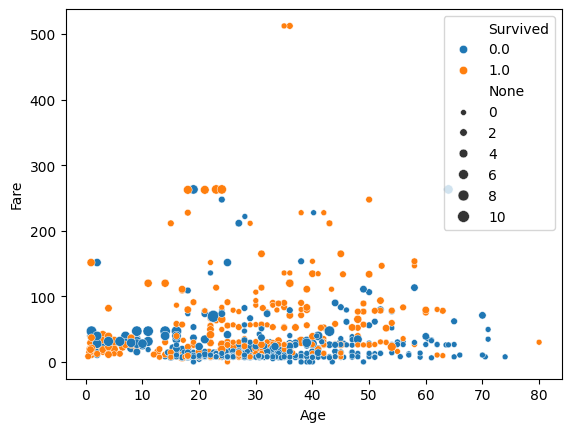

In [63]:
sns.scatterplot(x=titanic_file_encoded['Age'], y=titanic_file_encoded['Fare'],size=titanic_file_encoded['Parent_child']+titanic_file_encoded['SibSp'],hue=titanic_file_encoded['Survived'])

<Axes: xlabel='Age', ylabel='Fare'>

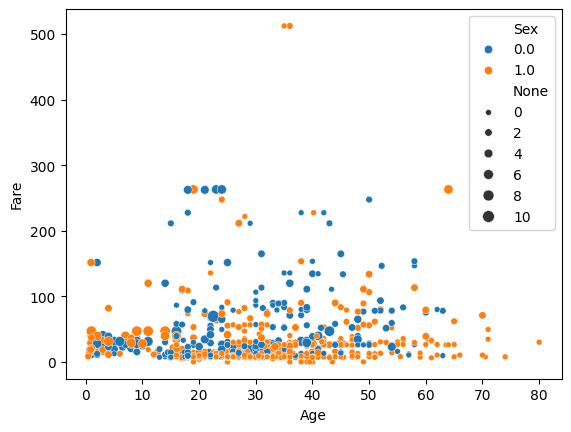

In [64]:
sns.scatterplot(x=titanic_file_encoded['Age'], y=titanic_file_encoded['Fare'],size=titanic_file_encoded['Parent_child']+titanic_file_encoded['SibSp'],hue=titanic_file_encoded['Sex'])

Females are more in higher Fare section & so is survived .

Non-linear distribution - better to use Random Forest regression/ Gradient Boosted trees.

SVM Non-linear kernel -need to check

There are local outliers too - for outlier detection maybe use LOF for outlier detection

In [65]:
#detecting outliers using LOF
#pass scaled data as LOF is distance based, sensitive to scale
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
        # Assuming 'data' is a 2D array or DataFrame
model = LocalOutlierFactor(n_neighbors=20, contamination='auto')
outlier_predictions = model.fit_predict(titanic_file_encoded_scaled) # -1 for outliers, 1 for inliers
outlier_predictions

#how many outliers out of total records?
np.where(outlier_predictions < 0) #returns index of the records which are outliers-could be local/global in the dataset
print("index of outliers in the dataset",np.where(outlier_predictions < 0)[0]) #1D array
print("number of outliers in dataset",len(np.where(outlier_predictions < 0)[0])) #number of outliers
print("Percentage of data which are outliers", len(np.where(outlier_predictions < 0)[0])/len(titanic_file_encoded_scaled))

#create a column in dataframe to mark the record as outlier or not
titanic_file_encoded_scaled["outlier"]=model.fit_predict(titanic_file_encoded_scaled)
titanic_file_encoded_scaled["outlier"]=titanic_file_encoded_scaled["outlier"]/10



index of outliers in the dataset [ 13  25  39  73  74 110 130 136 151 152 161 170 171 183 187 214 224 243
 247 249 251 259 260 265 283 314 320 340 347 379 389 390 433 436 444 446
 456 457 464 481 512 513 532 544 555 564 567 570 599 600 605 612 618 633
 636 649 650 652 674 685 686 699 712 716 720 727 731 743 748 751 755 779]
number of outliers in dataset 72
Percentage of data which are outliers 0.09183673469387756


In [66]:
#scaling outlier column
titanic_file_encoded_scaled["outlier"]=(titanic_file_encoded_scaled["outlier"]/10)
#view records which have been identified as outliers
titanic_file_encoded_scaled[titanic_file_encoded_scaled["outlier"]<0]

,Survived,Age,Fare,Cabin_not_allotment,Sex,Pclass,Parent_child,SibSp,outlier
13,0.0,0.574060,0.589999,0.0,0.0,0.0,5.0,1.0,-0.01
25,1.0,0.518505,0.594316,0.0,-1.0,0.0,5.0,1.0,-0.01
39,1.0,-0.814829,-0.178757,0.0,-1.0,0.0,0.0,1.0,-0.01
73,1.0,0.185171,1.557821,0.0,0.0,0.0,0.0,0.0,-0.01
74,0.0,-0.203718,-0.316585,-1.0,0.0,0.0,0.0,0.0,-0.01
...,...,...,...,...,...,...,...,...,...
743,0.0,-0.703718,-0.207219,0.0,0.0,-0.5,0.0,0.0,-0.01
748,0.0,-0.037051,0.656194,0.0,0.0,-0.5,1.0,0.0,-0.01
751,0.0,2.518505,-0.311788,0.0,0.0,0.0,0.0,0.0,-0.01
755,1.0,-0.592606,-0.251349,0.0,-1.0,0.0,1.0,0.0,-0.01


In [67]:
#stats of non outlier
titanic_file_encoded_scaled[titanic_file_encoded_scaled["outlier"]>0.0].describe()

,Survived,Age,Fare,Cabin_not_allotment,Sex,Pclass,Parent_child,SibSp,outlier
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,7.120000e+02
mean,0.424157,0.071993,0.704505,-0.269663,-0.386236,-0.396770,0.397472,0.540730,1.000000e-02
std,0.494562,0.798339,1.707019,0.444097,0.487228,0.431141,0.744899,0.941928,1.510270e-16
min,0.000000,-1.569273,-0.610146,-1.000000,-1.000000,-1.000000,0.000000,0.000000,1.000000e-02
25%,0.000000,-0.425940,-0.301235,-1.000000,-1.000000,-1.000000,0.000000,0.000000,1.000000e-02
50%,0.000000,0.018505,0.030699,0.000000,0.000000,-0.500000,0.000000,0.000000,1.000000e-02
75%,1.000000,0.574060,0.722990,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000e-02
max,1.000000,2.851838,9.482201,0.000000,0.000000,0.000000,4.000000,5.000000,1.000000e-02


In [68]:
#stats of outliers
titanic_file_encoded_scaled[titanic_file_encoded_scaled["outlier"]<0].describe()

,Survived,Age,Fare,Cabin_not_allotment,Sex,Pclass,Parent_child,SibSp,outlier
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000,7.200000e+01
mean,0.291667,0.055490,0.893702,-0.152778,-0.250000,-0.194444,0.597222,0.347222,-1.000000e-02
std,0.457719,0.788193,3.869072,0.362298,0.436051,0.341450,1.459883,1.344365,5.240691e-18
min,0.000000,-1.481495,-0.610146,-1.000000,-1.000000,-1.000000,0.000000,0.000000,-1.000000e-02
25%,0.000000,-0.537051,-0.311788,0.000000,-0.250000,-0.500000,0.000000,0.000000,-1.000000e-02
50%,0.000000,-0.037051,-0.121358,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e-02
75%,1.000000,0.574060,0.528121,0.000000,0.000000,0.000000,0.000000,0.000000,-1.000000e-02
max,1.000000,2.518505,19.049946,0.000000,0.000000,0.000000,6.000000,8.000000,-1.000000e-02


Comparing stats of outlier data vs normal data

Fare is the only one with significant differences in max value, mean, std dev

Others there are slight variations but not that much

Handling outliers:
Not removing directly as outliers have meaning in this dataset like extreme values of Fare

Transformation -Log or Box-Cox to compress range of data but will keep the shape intact.

Either cap OR split into categories of Fare range as a new feature OR add a new column to indicate too high Fare unusually high.

Since we got best accuracy till now by dropping Pclass and Cabin_not_allotment, doing the same here with YJ transformed data

In [69]:
#checking performance of logistic regression by applying transformation on Fare
# For heavily skewed data, PowerTransformer (Yeo-Johnson) is a good choice
#The Yeo-Johnson method is preferred over Box-Cox because it can handle features that contain zero or negative values.
# It finds the optimal lambda to make the distribution as Normal as possible.
from sklearn.preprocessing import PowerTransformer
X_train=titanic_file_encoded.drop(['Survived','Pclass','Cabin_not_allotment'],axis=1,inplace=False)
y_train=titanic_file_encoded['Survived']
X_test=titanic_test_encoded.drop(['Survived','Pclass','Cabin_not_allotment'],axis=1,inplace=False)
y_test=titanic_test_encoded['Survived']

#apply transofrmation first and then scale as scaling could distort data distribution
#PowerTransformer(method='yeo-johnson') - set standardize=False as standardize default method for scaling won't handle outliers well.
titanic_file_encoded.head()
yj=PowerTransformer(method='yeo-johnson',standardize=False)
X_train_yj=yj.fit_transform(X_train)
X_test_yj=yj.transform(X_test)

# Convert NumPy arrays back to DataFrames before concatenation
X_train_yj_df = pd.DataFrame(X_train_yj, columns=X_train.columns)
X_test_yj_df = pd.DataFrame(X_test_yj, columns=X_test.columns)


#transformation is done. Let's merge X,y and apply robust scaling
titanic_train_transformed=pd.concat([X_train_yj_df,y_train],axis=1)
titanic_test_transformed=pd.concat([X_test_yj_df,y_test],axis=1)

columns_chosen=titanic_train_transformed.columns
titanic_train_scaled_data5=robust_scale_Data(titanic_train_transformed)
titanic_train_scaled_data5=pd.DataFrame(titanic_train_scaled_data5,columns=columns_chosen)
titanic_train_scaled_data5.head()

columns_chosen=titanic_test_transformed.columns
titanic_test_scaled_data5=robust_scale_Data(titanic_test_transformed)
titanic_test_scaled_data5=pd.DataFrame(titanic_test_scaled_data5,columns=columns_chosen)
titanic_test_scaled_data5.head()

,Age,Fare,Sex,Parent_child,SibSp,Survived
0,-0.365295,-0.512831,0.0,-0.0,1.0,0.0
1,0.571751,1.119765,-1.0,-0.0,1.0,1.0
2,-0.119586,-0.446620,-1.0,-0.0,-0.0,1.0
3,0.404306,0.923677,-1.0,-0.0,1.0,1.0
4,0.404306,-0.434970,0.0,-0.0,-0.0,0.0


In [70]:
#Transformation applied throughout the table and scaled.
apply_logistic_regression(titanic_train_scaled_data5,titanic_test_scaled_data5)

accuracy for test data  0.7878787878787878


Close but accuracy is less than without Transformation but feature selection ie. dropping ,'Pclass','Cabin_not_allotment' - simple logistic regression - 0.79

/tmp/ipython-input-3310012206.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(titanic_file_encoded['Fare'])


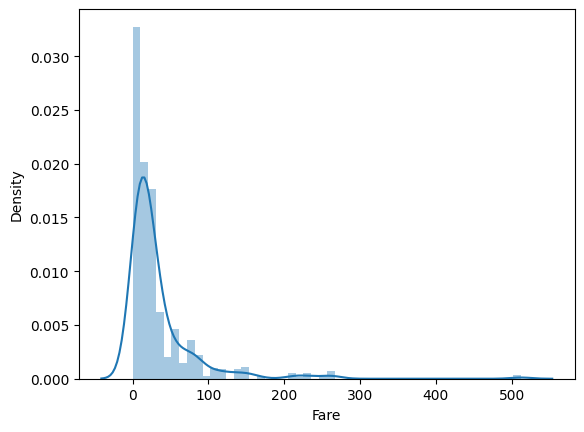

In [71]:
#checking performance of logistic regression by capping Fare-Winsoriz method
#how to decide threshold of percentile/quantile? visualize before capping, how many outliers?
sns.distplot(titanic_file_encoded['Fare'])
upper_limit=titanic_file_encoded['Fare'].quantile(0.95)
lower_limit=titanic_file_encoded['Fare'].quantile(0.01) #doesn't make sense as there are no outliers to lower side

 #above 262.375 there are 7 records. Most of them had 263 and a few 500+. Capping 500+ to 270
if (titanic_file_encoded['Fare'] > 263).any():
  titanic_file_encoded['Fare']=titanic_file_encoded['Fare'].apply(lambda x: 270 if x > 263 else x)

#apply the same on test data
if (titanic_test_encoded['Fare'] > 263).any():
  titanic_test_encoded['Fare']=titanic_test_encoded['Fare'].apply(lambda x: 270 if x > 263 else x)


In [72]:
#testing accuracy after capping Fare and removing Pclass, Cabin_not_allotment
columns_chosen=titanic_file_encoded.columns
titanic_train_scaled_data6=robust_scale_Data(titanic_file_encoded)
titanic_train_scaled_data6=pd.DataFrame(titanic_train_scaled_data6,columns=columns_chosen)
titanic_train_scaled_data6.head()

columns_chosen=titanic_test_encoded.columns
titanic_test_scaled_data6=robust_scale_Data(titanic_test_encoded)
titanic_test_scaled_data6=pd.DataFrame(titanic_test_scaled_data6,columns=columns_chosen)
titanic_test_scaled_data6.head()

apply_logistic_regression(titanic_train_scaled_data6.drop(['Pclass','Cabin_not_allotment'],axis=1,inplace=False),titanic_test_scaled_data6.drop(['Pclass','Cabin_not_allotment'],axis=1,inplace=False))

accuracy for test data  0.792368125701459


Accuracy with just capping Fare reduced further -.7575

After removing Pclass, cabin_Allotment and capping at 270 for Fare: 0.79236 similar to simple logistic regression without capping Fare

Aggressive capping at 95th quartile - accuracy reduced to 0.7901

Alternative to logistic regression which would be less sensitive to outliers-

Huber regression (combines squared and absolute loss for resilience to outliers) - for small dataset with outliers

Random forest classifier- for small-medium dataset, good for outliers

XGBoost forest classification- suitable for large dataset, outliers won't impact. Hyperparameter tuning critical

So here I'm going to choose Huber regression ,Random forest and compare performace against logistic regression model built earlier

In [73]:
#Random Forest implementation
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

X_train=titanic_file_encoded.drop(['Survived'],axis=1,inplace=False)
y_train=titanic_file_encoded['Survived']

titanic_test.Cabin_not_allotment=titanic_test.Cabin_not_allotment.astype(int)

X_test=titanic_test.drop(['Survived'],axis=1,inplace=False)
y_test=titanic_test['Survived']
rfc=RandomForestClassifier(n_estimators=50,random_state=42)
rfc.fit(X_train,y_train)
y_test_pred=rfc.predict(X_test)
print("accuracy for test data ",accuracy_score(y_test,y_test_pred) )

accuracy for test data  0.9719416386083053


Without any hyperparameter tuning, there's tremendous improvement in accuracy

A side note, should have performed cross validation using training data to get better idea of accuracy

In [74]:
categorical_cols

['Embarked', 'Sex', 'Survived', 'Pclass', 'Cabin', 'Cabin_not_allotment']

In [75]:
titanic_file.columns


Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parent_child', 'Fare',
       'Cabin', 'Embarked', 'Cabin_not_allotment'],
      dtype='object')

In [111]:
#SVC
#downsize data - would be done if data volume was too high like in ten thousands or more
#step1split training data into survived, dead categories
#step2use resample on this
#here we have less than 1000, so ignoring downsampling
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV



In [147]:
#define function for scv pre-processing

def scv_preprocessing_data(df,categorical_features,target):
  #onehot encoding for categorical data, no label encoding

  #Create the ColumnTransformer
  # The list of instructions (transformers) is a list of tuples:
  # ('name', transformer_object, columns_to_apply)
  # We set `remainder='passthrough'` to keep the other columns (Age) unchanged.
  preprocessor = ColumnTransformer(
      transformers=[
          ('onehot', OneHotEncoder(), categorical_features)
      ],
      remainder='passthrough'
  )

  # 3. Apply the transformation
  # Use `fit_transform` on your training data. Index is lost!!
  transformed_numpy = preprocessor.fit_transform(df)
  # The result is a NumPy array.
  columns_df=df.columns
  #convert it back to dataframe. get_feature_names_out gives list of new column names that will be generated after transformation
  new_column_names = preprocessor.get_feature_names_out(input_features=columns_df)
  train_OHencoded_df=pd.DataFrame(transformed_numpy, columns=new_column_names)

  #impute missing values
  imputer=KNNImputer(n_neighbors=2,weights='distance',metric='nan_euclidean')
  train_OHencoded_df=pd.DataFrame(imputer.fit_transform(train_OHencoded_df),columns=train_OHencoded_df.columns)

  #robust scaling
  scaled_encoded_scv_np=robust_scale_Data(train_OHencoded_df)
  scaled_encoded_scv_df=pd.DataFrame(scaled_encoded_scv_np,columns=train_OHencoded_df.columns)


  return scaled_encoded_scv_df


In [152]:
#pre-process train data
categorical_features = ['Sex', 'Pclass', 'Cabin_not_allotment']
train_scv_preprocessed_df = scv_preprocessing_data(titanic_file.drop(['Cabin', 'Embarked'], axis=1, inplace=False), categorical_features,'Survived')

X_train_scv=train_scv_preprocessed_df.drop(['remainder__Survived'], axis=1,inplace=False)
y_train_scv=train_scv_preprocessed_df['remainder__Survived']

In [153]:
X_train_scv.columns

Index(['onehot__Sex_female', 'onehot__Sex_male', 'onehot__Pclass_1',
       'onehot__Pclass_2', 'onehot__Pclass_3',
       'onehot__Cabin_not_allotment_0.0', 'onehot__Cabin_not_allotment_1.0',
       'remainder__Age', 'remainder__SibSp', 'remainder__Parent_child',
       'remainder__Fare'],
      dtype='object')

In [159]:
desired_sequence_columns=titanic_file.columns.tolist()
desired_sequence_columns.remove('Cabin')
desired_sequence_columns.remove('Embarked')
desired_sequence_columns
#align test dataset and train dataset in same order, same names
titanic_test_rearranged=titanic_test[desired_sequence_columns]
titanic_test_rearranged

['Survived',
 'Pclass',
 'Sex',
 'Age',
 'SibSp',
 'Parent_child',
 'Fare',
 'Cabin_not_allotment']

In [162]:
categorical_features = ['Sex', 'Pclass', 'Cabin_not_allotment']
test_scv_preprocessed_df = scv_preprocessing_data(titanic_test_rearranged, categorical_features,'Survived')

X_test_scv=test_scv_preprocessed_df.drop(['remainder__Survived'], axis=1,inplace=False)
y_test_scv=test_scv_preprocessed_df['remainder__Survived']

In [165]:
X_test_scv.columns

Index(['onehot__Sex_0', 'onehot__Sex_1', 'onehot__Pclass_1',
       'onehot__Pclass_2', 'onehot__Pclass_3', 'onehot__Cabin_not_allotment_0',
       'onehot__Cabin_not_allotment_1', 'remainder__Age', 'remainder__SibSp',
       'remainder__Parent_child', 'remainder__Fare'],
      dtype='object')

In [166]:
X_train_scv.columns

Index(['onehot__Sex_female', 'onehot__Sex_male', 'onehot__Pclass_1',
       'onehot__Pclass_2', 'onehot__Pclass_3',
       'onehot__Cabin_not_allotment_0.0', 'onehot__Cabin_not_allotment_1.0',
       'remainder__Age', 'remainder__SibSp', 'remainder__Parent_child',
       'remainder__Fare'],
      dtype='object')

In [163]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

#ensure train and test data follow same column order and name
my_dict = dict(zip(X_test_scv.columns,X_train_scv.columns))

X_test_scv_renamed=X_test_scv.copy()
X_test_scv_renamed=X_test_scv.rename(columns=my_dict)
X_test_scv_renamed.columns

In [178]:
#applying SVC preliminary
svc=SVC()
svc.fit(X_train_scv,y_train_scv)
y_test_pred_scv=svc.predict(X_test_scv_renamed)
print("accuracy for test data ",accuracy_score(y_test_scv,y_test_pred_scv) )


accuracy for test data  0.8316498316498316


Choose soft margin, gamma for optimizing SCV model

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV 1/5] END ..........C=0.1, gamma=1; accuracy: (test=0.688) total time=   0.0s
[CV 2/5] END ..........C=0.1, gamma=1; accuracy: (test=0.764) total time=   0.0s
[CV 3/5] END ..........C=0.1, gamma=1; accuracy: (test=0.764) total time=   0.1s
[CV 4/5] END ..........C=0.1, gamma=1; accuracy: (test=0.745) total time=   0.0s
[CV 5/5] END ..........C=0.1, gamma=1; accuracy: (test=0.776) total time=   0.0s
[CV 1/5] END ........C=0.1, gamma=0.1; accuracy: (test=0.758) total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=0.1; accuracy: (test=0.809) total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=0.1; accuracy: (test=0.771) total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=0.1; accuracy: (test=0.732) total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=0.1; accuracy: (test=0.821) total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=0.01; accuracy: (test=0.618) total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=0.01; accuracy: 

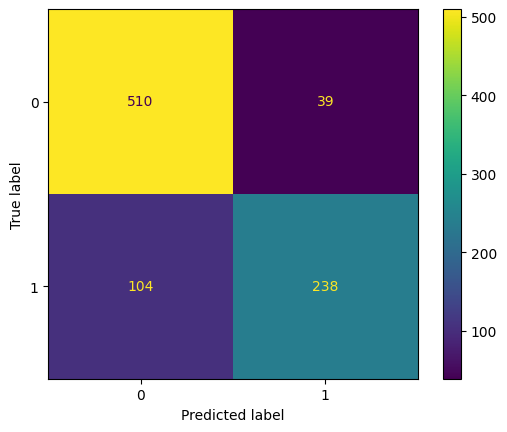

In [183]:
from sklearn.model_selection import GridSearchCV
#selecting optimum values for soft margin c, gamma - parameter for Radial basis function used by radial kernel
#by GridSearchCV

param_grid = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01]}
#we'll use rbf kernel as it is said to perform well usually
gr=GridSearchCV(SVC(kernel='rbf'),param_grid,refit='accuracy',verbose=3,scoring=['accuracy'])
#refit=True will use all of the training data rather than subsets used in cross validation.
#Additionally, It will directly apply best parameter combination on training data
# so that we can skip this step and use fit on test data
gr.fit(X_train_scv,y_train_scv)
#apply predict on test data
y_test_predict=gr.predict(X_test_scv_renamed)
print("accuracy for test data ",accuracy_score(y_test_scv,y_test_predict))
#confusion matrix
ConfusionMatrixDisplay(confusion_matrix(y_test_scv,y_test_predict)).plot()


Even after optimization of SCV, score didn't improve much. Random Forest gave best results